# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown. 

In this case, we are facing a Discontinuous function

In [2]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [ ]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5-0.5)-5.)*(x<2.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.)*(x>2.5)
highfid = lambda x: (2*lowfid(x)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x)- 20*x/5.+20)*(x/5.>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

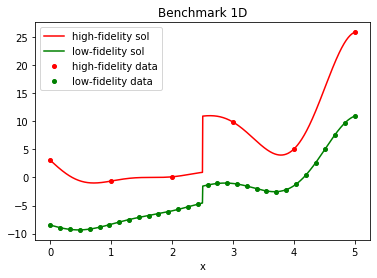

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

NameError: name 'Neural_network' is not defined

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

Test MSE: 0.039483146055228645
R^2: 0.9982761183378721


## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 0.006740412127449255
R^2: 0.9997057054965822


## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

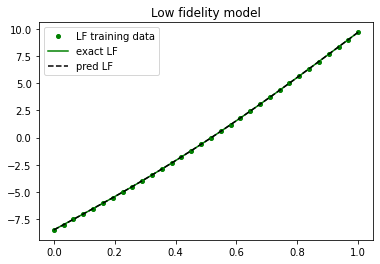

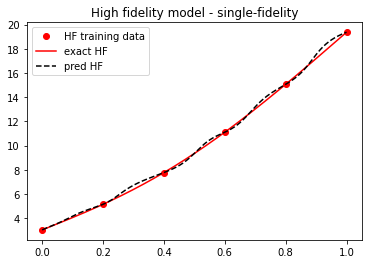

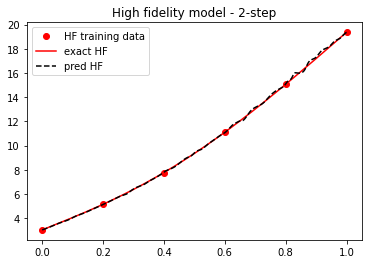

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1 
sigma=0.1  
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =10000
burnin = 3000
n_chains=2

# Multifidelity

In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 10000/10000 [23:14<00:00,  7.17it/s]


Sampling chain 2/2


Running chain, α = 0.17:  22%|██▏       | 2182/10000 [05:34<1:00:27,  2.16it/s]

: 

### Low Fidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.71: 100%|██████████| 10000/10000 [12:49<00:00, 13.00it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 9001), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 9001), minimum_shape: (chains=2, draws=4)


estimated values are [2.94  2.403 4.278 2.637]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.940  1.993   0.259    7.291      0.806    0.600       6.0      20.0   
x1  2.403  0.756   1.266    3.952      0.330    0.256       6.0      11.0   
x2  4.278  1.638   1.872    7.291      1.356    1.268       2.0      20.0   
x3  2.637  2.165  -0.802    5.450      2.038    2.315       1.0      24.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Autocorrelation...


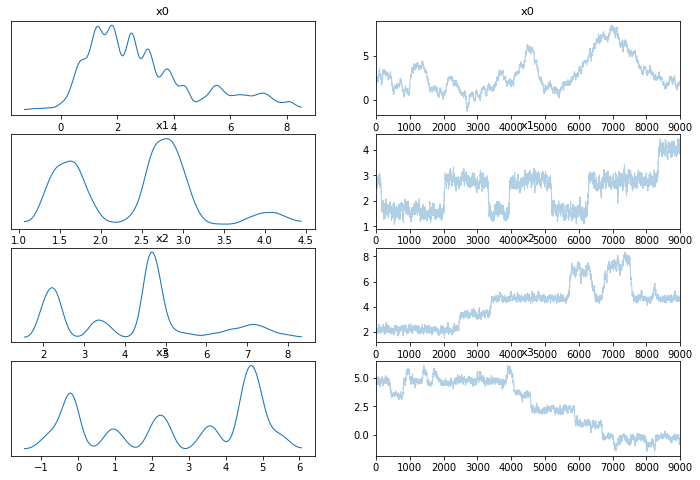

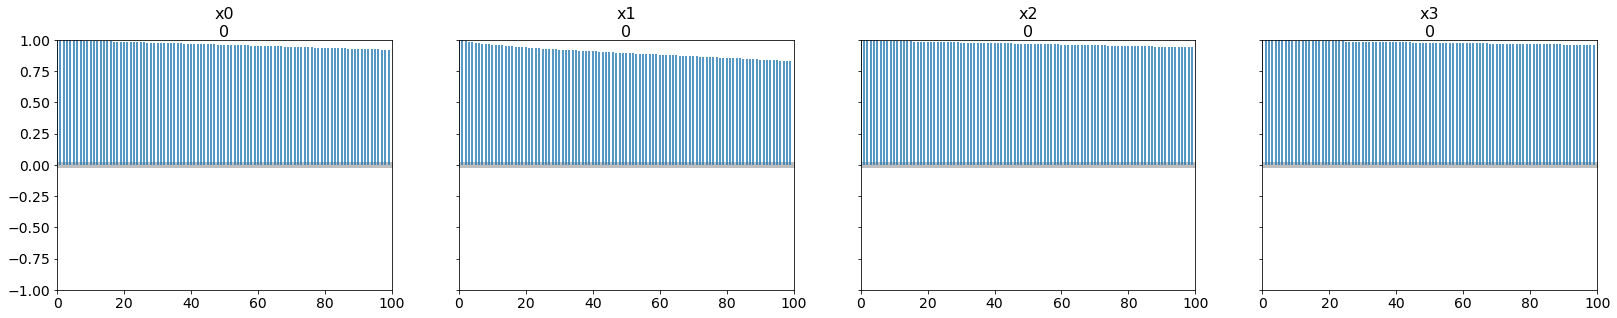

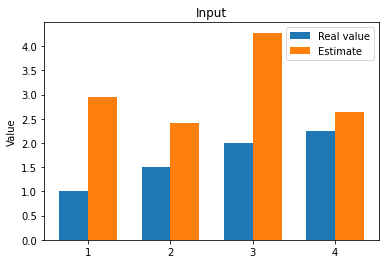

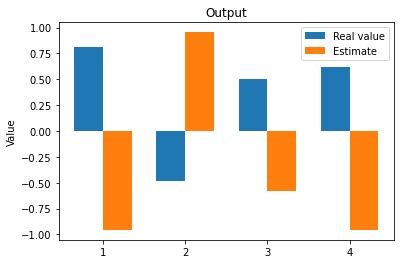

In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=lowfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
